# 05 — Performance metrics, temporal aggregation and PLR input preparation

This notebook prepares the performance-ratio inputs used for PLR estimation.

The irradiance-filtered row-level datasets (`g200`, `g400`, and `sunny`) are created in Notebook 04. This notebook:

1. loads the irradiance-filtered row-level datasets;
2. calculates raw and temperature-corrected DC performance ratios;
3. applies broad performance-metric validity checks;
4. adds fleet-relative diagnostic metrics for later shading analysis;
5. aggregates row-level data to 15-minute, daily, and monthly PLR inputs;
6. applies module-wise daily IQR filtering;
7. saves the final PLR-ready datasets.

The main PLR metric is the temperature-corrected DC performance ratio, \(PR_\mathrm{DC,25C}\).

## 1. Imports and plotting style

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 12,
    "legend.title_fontsize": 12,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 14
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 12

## 2. Project paths

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DIRS = {
    "data_processed": PROJECT_ROOT / "data_processed",
    "figures": PROJECT_ROOT / "figures",
    "tables": PROJECT_ROOT / "tables",
}

FINAL_FIG_DIR = DIRS["figures"] / "final figures"
FINAL_TABLE_DIR = DIRS["tables"] / "final tables"

IRRADIANCE_QC_DIR = DIRS["data_processed"] / "irradiance_qc"
PERFORMANCE_METRIC_DIR = DIRS["data_processed"] / "performance_metrics"
PLR_INPUT_DIR = DIRS["data_processed"] / "plr_final_inputs"

for folder in [FINAL_FIG_DIR, FINAL_TABLE_DIR, PERFORMANCE_METRIC_DIR, PLR_INPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

G200_INPUT_PATH = IRRADIANCE_QC_DIR / "df_g200.parquet"
G400_INPUT_PATH = IRRADIANCE_QC_DIR / "df_g400.parquet"
SUNNY_INPUT_PATH = IRRADIANCE_QC_DIR / "df_sunny.parquet"

G200_METRICS_OUTPUT_PATH = PERFORMANCE_METRIC_DIR / "df_g200_metrics.parquet"
G400_METRICS_OUTPUT_PATH = PERFORMANCE_METRIC_DIR / "df_g400_metrics.parquet"
SUNNY_METRICS_OUTPUT_PATH = PERFORMANCE_METRIC_DIR / "df_sunny_metrics.parquet"

print("Project root:", PROJECT_ROOT)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)
print("Performance metric folder:", PERFORMANCE_METRIC_DIR)
print("PLR input folder:", PLR_INPUT_DIR)

Project root: C:\Users\amina\Thesis\Final Pipeline
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables
Performance metric folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\performance_metrics
PLR input folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\plr_final_inputs


## 3. Helper functions

In [7]:
def save_fig(filename, fig=None):
    """
    Save the active figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def standardise_metric_input_columns(df_input):
    """
    Standardise raw electrical and environmental column names for metric calculation.

    Module type is not required at this stage because it is added later from
    the module reference table.
    """
    df_out = df_input.copy()

    rename_map = {
        "MPP": "P_MPP",
        "VMP": "V_MPP",
        "IMP": "I_MPP",
        "VOC": "V_OC",
        "ISC": "I_SC",
        "Temp": "T_module",
        "POA_GLOBAL": "G_POA",
        "G": "G_POA",
    }

    for old_col, new_col in rename_map.items():
        if old_col in df_out.columns and new_col not in df_out.columns:
            df_out = df_out.rename(columns={old_col: new_col})

    for col in ["Datetime_Local", "Datetime_UTC", "Datetime_Bin_Local", "Datetime_Bin_UTC"]:
        if col in df_out.columns:
            if col == "Datetime_Bin_UTC":
                df_out[col] = pd.to_datetime(df_out[col], utc=True)
            else:
                df_out[col] = pd.to_datetime(df_out[col])

    local_time = pd.to_datetime(df_out["Datetime_Bin_Local"])

    if local_time.dt.tz is not None:
        local_time_naive = local_time.dt.tz_localize(None)
    else:
        local_time_naive = local_time

    df_out["Date"] = local_time_naive.dt.floor("D")
    df_out["Year"] = local_time_naive.dt.year
    df_out["Month"] = local_time_naive.dt.month
    df_out["Day"] = local_time_naive.dt.day
    df_out["Hour"] = local_time_naive.dt.hour
    df_out["Minute"] = local_time_naive.dt.minute
    df_out["DayOfYear"] = local_time_naive.dt.dayofyear
    df_out["YearMonth"] = local_time_naive.dt.to_period("M").astype(str)

    required_cols = [
        "Module_ID",
        "Datetime_Local",
        "Datetime_Bin_Local",
        "Datetime_Bin_UTC",
        "Date",
        "G_POA",
        "P_MPP",
        "V_MPP",
        "I_MPP",
        "V_OC",
        "I_SC",
        "T_module",
    ]

    missing_cols = [col for col in required_cols if col not in df_out.columns]

    if missing_cols:
        raise ValueError(f"Missing required columns after standardisation: {missing_cols}")

    return df_out

## 4. Constants and module metadata

Reference module parameters are taken from the module datasheet and applied consistently across all ten modules.

In [4]:
G_STC = 1000.0
T_STC = 25.0

MAX_VALID_PR = 1.20
MAX_VALID_FF = 1.00
MAX_VALID_I_MPP_OVER_I_SC = 1.05
MAX_VALID_V_MPP_OVER_V_OC = 1.00

MIN_MODULES_PER_FLEET_BIN = 8

BIN_HOURS = 15 / 60
MIN_ROWS_DAY = 10
MIN_DAYS_MONTH = 10
IQR_MULT = 1.5

MAIN_METRIC = "PR_25C"

In [5]:
module_ref = pd.DataFrame({
    "Module_ID": list(range(1, 11)),
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
    "P_STC": [150.0] * 10,
    "I_MPP_STC": [8.22] * 10,
    "V_MPP_STC": [18.79] * 10,
    "I_SC_STC": [8.61] * 10,
    "V_OC_STC": [22.21] * 10,

    # Datasheet temperature coefficients in fractional units per °C
    "gamma_Pmp": [-0.0041] * 10,
    "alpha_Isc": [0.0005] * 10,
    "beta_Voc": [-0.0031] * 10,
})

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
}

MODULE_COLORS = {
    1: "#0072B2",
    2: "#1B9E77",
    3: "#D55E00",
    4: "#E69F00",
    5: "#009E73",
    6: "#CC6677",
    7: "#B8860B",
    8: "#A0522D",
    9: "#8B5A2B",
    10: "#66A61E",
}

module_ref["Color"] = module_ref["Module_ID"].map(MODULE_COLORS)

MODULE_TYPE_MAP = dict(zip(module_ref["Module_ID"], module_ref["Type"]))
MODULE_COLOR_MAP = dict(zip(module_ref["Module_ID"], module_ref["Color"]))

legend_handles_type = [
    Patch(facecolor=TYPE_COLORS["Reference"], label="Reference"),
    Patch(facecolor=TYPE_COLORS["PID/Reference"], label="PID/Reference"),
    Patch(facecolor=TYPE_COLORS["uCrack"], label="uCrack"),
]

display(module_ref)

module_ref.to_csv(
    FINAL_TABLE_DIR / "module_reference_parameters.csv",
    index=False,
)

,Module_ID,Type,P_STC,I_MPP_STC,V_MPP_STC,I_SC_STC,V_OC_STC,gamma_Pmp,alpha_Isc,beta_Voc,Color
0,1,PID/Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#0072B2
1,2,Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#1B9E77
2,3,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#D55E00
3,4,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#E69F00
4,5,Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#009E73
5,6,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#CC6677
6,7,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#B8860B
7,8,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#A0522D
8,9,uCrack,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#8B5A2B
9,10,Reference,150.0,8.22,18.79,8.61,22.21,-0.0041,0.0005,-0.0031,#66A61E


## 5. Load irradiance-filtered row-level datasets

The g200, g400, and sunny row-level datasets were created in Notebook 04. They are loaded here as inputs for performance-metric calculation.

In [8]:
datasets_raw = {
    "g200": pd.read_parquet(G200_INPUT_PATH),
    "g400": pd.read_parquet(G400_INPUT_PATH),
    "sunny": pd.read_parquet(SUNNY_INPUT_PATH),
}

datasets = {}

for dataset_name, dataset in datasets_raw.items():
    temp = standardise_metric_input_columns(dataset)

    metadata_cols = [
        "Type",
        "P_STC",
        "I_MPP_STC",
        "V_MPP_STC",
        "I_SC_STC",
        "V_OC_STC",
        "gamma_Pmp",
        "alpha_Isc",
        "beta_Voc",
        "Color",
    ]

    temp = temp.drop(
        columns=[col for col in metadata_cols if col in temp.columns],
        errors="ignore",
    )

    # Add module type and datasheet reference parameters from module_ref.
    temp = temp.merge(
        module_ref,
        on="Module_ID",
        how="left",
        validate="many_to_one",
    )

    if temp["Type"].isna().any():
        missing_modules = sorted(temp.loc[temp["Type"].isna(), "Module_ID"].unique())
        raise ValueError(f"Missing module metadata for modules: {missing_modules}")

    if temp["P_STC"].isna().any():
        missing_modules = sorted(temp.loc[temp["P_STC"].isna(), "Module_ID"].unique())
        raise ValueError(f"Missing reference parameters for modules: {missing_modules}")

    datasets[dataset_name] = temp

    print(f"{dataset_name}: {temp.shape}")
    print("Datetime range:", temp["Datetime_Local"].min(), "to", temp["Datetime_Local"].max())
    print("Modules:", sorted(temp["Module_ID"].unique()))
    print("-" * 80)

g200: (2186368, 45)
Datetime range: 2017-01-02 10:19:09+01:00 to 2021-12-27 14:56:01+01:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
g400: (1421918, 45)
Datetime range: 2017-01-02 10:57:56+01:00 to 2021-12-27 14:56:01+01:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------
sunny: (1164790, 45)
Datetime range: 2017-01-02 10:19:09+01:00 to 2021-12-27 14:56:01+01:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
--------------------------------------------------------------------------------


## 6. Calculate row-level performance metrics

Raw and temperature-corrected DC performance ratios are calculated at row level.

The main PLR metric is:

\[
PR_\mathrm{DC,25C} =
\frac{P_\mathrm{MPP,25C}}
{P_\mathrm{STC}\left(G_\mathrm{POA}/G_\mathrm{STC}\right)}
\]

where \(P_\mathrm{MPP,25C}\) is the measured maximum power corrected to 25°C using the datasheet power-temperature coefficient.

In [9]:
def calculate_performance_metrics(df_input):
    """
    Calculate row-level DC performance metrics.
    """
    df_out = df_input.copy()

    df_out["PR_raw"] = (
        df_out["P_MPP"]
        / (df_out["P_STC"] * (df_out["G_POA"] / G_STC))
    )

    df_out["P_MPP_25C"] = (
        df_out["P_MPP"]
        / (1 + df_out["gamma_Pmp"] * (df_out["T_module"] - T_STC))
    )

    df_out["PR_25C"] = (
        df_out["P_MPP_25C"]
        / (df_out["P_STC"] * (df_out["G_POA"] / G_STC))
    )

    df_out["FF_measured"] = (
        df_out["P_MPP"]
        / (df_out["V_OC"] * df_out["I_SC"])
    )

    df_out["I_MPP_over_I_SC"] = df_out["I_MPP"] / df_out["I_SC"]
    df_out["V_MPP_over_V_OC"] = df_out["V_MPP"] / df_out["V_OC"]

    return df_out


datasets_metrics = {}

for dataset_name, dataset in datasets.items():
    datasets_metrics[dataset_name] = calculate_performance_metrics(dataset)
    print(f"{dataset_name}: performance metrics calculated, shape = {datasets_metrics[dataset_name].shape}")

g200: performance metrics calculated, shape = (2186368, 51)
g400: performance metrics calculated, shape = (1421918, 51)
sunny: performance metrics calculated, shape = (1164790, 51)


## 7. Apply row-level metric validity checks

Broad validity checks are applied to remove non-physical or extreme metric artefacts. These checks are deliberately permissive so that low-performing but physically meaningful module behaviour is retained.

In [12]:
def apply_metric_validity_checks(df_input, dataset_name):
    """
    Apply broad row-level metric validity checks.
    """
    df_checked = df_input.copy()

    df_checked["valid_PR_raw"] = (
        df_checked["PR_raw"].notna()
        & np.isfinite(df_checked["PR_raw"])
        & (df_checked["PR_raw"] > 0)
        & (df_checked["PR_raw"] <= MAX_VALID_PR)
    )

    df_checked["valid_PR_25C"] = (
        df_checked["PR_25C"].notna()
        & np.isfinite(df_checked["PR_25C"])
        & (df_checked["PR_25C"] > 0)
        & (df_checked["PR_25C"] <= MAX_VALID_PR)
    )

    df_checked["valid_FF_measured"] = (
        df_checked["FF_measured"].notna()
        & np.isfinite(df_checked["FF_measured"])
        & (df_checked["FF_measured"] > 0)
        & (df_checked["FF_measured"] <= MAX_VALID_FF)
    )

    df_checked["valid_I_MPP_over_I_SC"] = (
        df_checked["I_MPP_over_I_SC"].notna()
        & np.isfinite(df_checked["I_MPP_over_I_SC"])
        & (df_checked["I_MPP_over_I_SC"] > 0)
        & (df_checked["I_MPP_over_I_SC"] <= MAX_VALID_I_MPP_OVER_I_SC)
    )

    df_checked["valid_V_MPP_over_V_OC"] = (
        df_checked["V_MPP_over_V_OC"].notna()
        & np.isfinite(df_checked["V_MPP_over_V_OC"])
        & (df_checked["V_MPP_over_V_OC"] > 0)
        & (df_checked["V_MPP_over_V_OC"] <= MAX_VALID_V_MPP_OVER_V_OC)
    )

    validity_cols = [
        "valid_PR_raw",
        "valid_PR_25C",
        "valid_FF_measured",
        "valid_I_MPP_over_I_SC",
        "valid_V_MPP_over_V_OC",
    ]

    df_checked["metric_valid"] = df_checked[validity_cols].all(axis=1)

    filter_summary = pd.DataFrame({
        "Dataset": dataset_name,
        "Check": validity_cols + ["metric_valid_all_checks"],
        "Failed records": [int((~df_checked[col]).sum()) for col in validity_cols]
        + [int((~df_checked["metric_valid"]).sum())],
        "Initial records": len(df_checked),
    })

    filter_summary["Failed [%]"] = (
        100 * filter_summary["Failed records"] / filter_summary["Initial records"]
    )

    df_valid = df_checked.loc[df_checked["metric_valid"]].copy()

    return df_valid, filter_summary


datasets_valid = {}
metric_validity_summaries = []

for dataset_name, dataset in datasets_metrics.items():
    datasets_valid[dataset_name], summary = apply_metric_validity_checks(
        dataset,
        dataset_name=dataset_name,
    )

    metric_validity_summaries.append(summary)

    print(f"{dataset_name}: {dataset.shape[0]:,} to {datasets_valid[dataset_name].shape[0]:,} records")

metric_validity_summary = pd.concat(metric_validity_summaries, ignore_index=True)

display(metric_validity_summary)

metric_validity_summary.to_csv(
    FINAL_TABLE_DIR / "row_level_metric_validity_summary.csv",
    index=False,
)

g200: 2,186,368 to 2,152,548 records
g400: 1,421,918 to 1,398,509 records
sunny: 1,164,790 to 1,143,927 records


,Dataset,Check,Failed records,Initial records,Failed [%]
0,g200,valid_PR_raw,17588,2186368,0.804439
1,g200,valid_PR_25C,16269,2186368,0.744111
2,g200,valid_FF_measured,14839,2186368,0.678706
3,g200,valid_I_MPP_over_I_SC,14670,2186368,0.670976
4,g200,valid_V_MPP_over_V_OC,0,2186368,0.000000
5,g200,metric_valid_all_checks,33820,2186368,1.546858
6,g400,valid_PR_raw,10738,1421918,0.755177
7,g400,valid_PR_25C,10615,1421918,0.746527
8,g400,valid_FF_measured,11429,1421918,0.803773
9,g400,valid_I_MPP_over_I_SC,11159,1421918,0.784785


## 8. Add fleet-relative diagnostic metrics

Fleet-relative metrics compare each module with the fleet median in the same 15-minute bin. These metrics are not used as the main PLR metric, but are retained for later shading and module-relative diagnostics.

This is where 15-minute binning is important for cross-module comparison: modules are compared only within the same timestamp bin.

In [13]:
def add_fleet_relative_metrics(df_input):
    """
    Add same-bin fleet-relative diagnostic metrics.
    """
    df_out = df_input.copy()

    metric_map = {
        "P_MPP": "P_MPP_rel_fleet",
        "I_MPP": "I_MPP_rel_fleet",
        "V_MPP": "V_MPP_rel_fleet",
        "PR_25C": "PR_25C_rel_fleet",
    }

    fleet_counts = (
        df_out.groupby("Datetime_Bin_Local")["Module_ID"]
        .nunique()
        .rename("fleet_n_modules_valid")
        .reset_index()
    )

    df_out = df_out.merge(
        fleet_counts,
        on="Datetime_Bin_Local",
        how="left",
        validate="many_to_one",
    )

    df_out["fleet_relative_valid"] = (
        df_out["fleet_n_modules_valid"] >= MIN_MODULES_PER_FLEET_BIN
    )

    for metric, rel_metric in metric_map.items():
        median_col = f"{metric}_fleet_median"

        fleet_median = (
            df_out.groupby("Datetime_Bin_Local")[metric]
            .median()
            .rename(median_col)
            .reset_index()
        )

        df_out = df_out.merge(
            fleet_median,
            on="Datetime_Bin_Local",
            how="left",
            validate="many_to_one",
        )

        df_out[rel_metric] = df_out[metric] / df_out[median_col]
        df_out.loc[~df_out["fleet_relative_valid"], rel_metric] = np.nan
        df_out.loc[(df_out[rel_metric] <= 0) | (df_out[rel_metric] > 2), rel_metric] = np.nan

    return df_out


datasets_valid = {
    dataset_name: add_fleet_relative_metrics(dataset)
    for dataset_name, dataset in datasets_valid.items()
}

for dataset_name, dataset in datasets_valid.items():
    print(dataset_name, dataset.shape)

g200 (2152548, 67)
g400 (1398509, 67)
sunny (1143927, 67)


## 9. Aggregate to module-level 15-minute bins

Row-level data are aggregated to a common module-level 15-minute timebase. This step is used to align module measurements to the same timestamp before daily aggregation and downstream cross-module diagnostics.

Daily and monthly \(PR_\mathrm{DC,25C}\) are not calculated as medians of 15-minute PR values. They are calculated later using yield-based ratios of sums.

In [14]:
def aggregate_to_15min(df_input, dataset_name):
    """
    Aggregate row-level metric data to module-level 15-minute bins.
    """
    group_cols = [
        "Module_ID",
        "Type",
        "Datetime_Bin_Local",
        "Datetime_Bin_UTC",
    ]

    agg_dict = {
        "Datetime_Local": "median",
        "Date": "first",
        "Year": "first",
        "Month": "first",
        "Day": "first",
        "Hour": "first",
        "Minute": "first",
        "DayOfYear": "first",
        "YearMonth": "first",

        "G_POA": "median",
        "G_POA_clear_sky": "median",
        "solar_apparent_elevation_deg": "median",
        "is_daytime_solar": "max",
        "is_daylight_analysis_bin": "max",
        "Irradiance_Class": "first",

        "P_MPP": "median",
        "P_MPP_25C": "median",
        "V_MPP": "median",
        "I_MPP": "median",
        "V_OC": "median",
        "I_SC": "median",
        "T_module": "median",

        "P_STC": "first",
        "PR_raw": "median",
        "PR_25C": "median",
        "FF_measured": "median",
        "I_MPP_over_I_SC": "median",
        "V_MPP_over_V_OC": "median",

        "P_MPP_rel_fleet": "median",
        "I_MPP_rel_fleet": "median",
        "V_MPP_rel_fleet": "median",
        "PR_25C_rel_fleet": "median",
        "fleet_n_modules_valid": "median",
        "fleet_relative_valid": "max",
    }

    available_agg_dict = {
        col: func for col, func in agg_dict.items()
        if col in df_input.columns
    }

    binned = (
        df_input.groupby(group_cols, as_index=False)
        .agg(available_agg_dict)
        .sort_values(["Module_ID", "Datetime_Bin_Local"])
        .reset_index(drop=True)
    )

    binned["dataset"] = dataset_name

    return binned


binned15_datasets = {}

for dataset_name, dataset in datasets_valid.items():
    binned15_datasets[dataset_name] = aggregate_to_15min(dataset, dataset_name)
    print(dataset_name, binned15_datasets[dataset_name].shape)

g200 (304972, 39)
g400 (214365, 39)
sunny (135745, 39)


## 10. Aggregate to daily PLR inputs

Daily \(PR_\mathrm{DC,25C}\) is calculated as a yield-based ratio of sums:

\[
PR_{\mathrm{DC,25C,day}} =
\frac{\sum P_{\mathrm{MPP,25C}}\Delta t}
{\sum P_{\mathrm{STC}}\left(G_\mathrm{POA}/G_\mathrm{STC}\right)\Delta t}
\]

A daily value is retained only when at least 10 valid 15-minute observations are available for that module-day.

In [15]:
def safe_ratio(numerator, denominator):
    if pd.isna(denominator) or denominator <= 0:
        return np.nan
    return numerator / denominator


def aggregate_one_day(group):
    group = group.copy()

    energy_raw_Wh = (group["P_MPP"] * BIN_HOURS).sum()
    energy_25C_Wh = (group["P_MPP_25C"] * BIN_HOURS).sum()

    reference_energy_Wh = (
        group["P_STC"] * (group["G_POA"] / G_STC) * BIN_HOURS
    ).sum()

    H_POA_Wh_m2 = (group["G_POA"] * BIN_HOURS).sum()
    Y_ref_h = H_POA_Wh_m2 / G_STC

    return {
        "PR_25C": safe_ratio(energy_25C_Wh, reference_energy_Wh),
        "PR_raw": safe_ratio(energy_raw_Wh, reference_energy_Wh),

        "energy_raw_Wh": energy_raw_Wh,
        "energy_25C_Wh": energy_25C_Wh,
        "reference_energy_Wh": reference_energy_Wh,
        "H_POA_Wh_m2": H_POA_Wh_m2,
        "Y_ref_h": Y_ref_h,

        "P_MPP": group["P_MPP"].median(),
        "P_MPP_25C": group["P_MPP_25C"].median(),
        "P_STC": group["P_STC"].iloc[0],

        "G_POA": group["G_POA"].median(),
        "T_module": group["T_module"].median(),

        "FF_measured": group["FF_measured"].median(),
        "I_MPP_over_I_SC": group["I_MPP_over_I_SC"].median(),
        "V_MPP_over_V_OC": group["V_MPP_over_V_OC"].median(),

        "PR_25C_rel_fleet": group["PR_25C_rel_fleet"].median(),
        "P_MPP_rel_fleet": group["P_MPP_rel_fleet"].median(),
        "I_MPP_rel_fleet": group["I_MPP_rel_fleet"].median(),
        "V_MPP_rel_fleet": group["V_MPP_rel_fleet"].median(),

        "n_15min_day": group["Datetime_Bin_Local"].nunique(),
    }


def aggregate_to_daily(binned15_input, dataset_name):
    daily_rows = []

    for keys, group in binned15_input.groupby(["Module_ID", "Type", "Date"], sort=False):
        row = dict(zip(["Module_ID", "Type", "Date"], keys))
        row.update(aggregate_one_day(group))
        daily_rows.append(row)

    daily = pd.DataFrame(daily_rows)

    daily["Date"] = pd.to_datetime(daily["Date"])
    daily["Year"] = daily["Date"].dt.year
    daily["Month"] = daily["Date"].dt.month
    daily["Day"] = daily["Date"].dt.day
    daily["DayOfYear"] = daily["Date"].dt.dayofyear
    daily["YearMonth"] = daily["Date"].dt.to_period("M").astype(str)
    daily["dataset"] = dataset_name

    daily["daily_support_valid"] = daily["n_15min_day"] >= MIN_ROWS_DAY

    daily_supported = (
        daily.loc[daily["daily_support_valid"]]
        .sort_values(["Module_ID", "Date"])
        .reset_index(drop=True)
    )

    support_summary = pd.DataFrame([{
        "Dataset": dataset_name,
        "Daily records before support filter": len(daily),
        "Daily records after support filter": len(daily_supported),
        "Daily records excluded": len(daily) - len(daily_supported),
        "Minimum 15-min records per retained day": MIN_ROWS_DAY,
        "Median 15-min records per retained day": daily_supported["n_15min_day"].median(),
    }])

    return daily_supported, support_summary


daily_datasets = {}
daily_support_summaries = []

for dataset_name, binned15 in binned15_datasets.items():
    daily_datasets[dataset_name], summary = aggregate_to_daily(binned15, dataset_name)
    daily_support_summaries.append(summary)

daily_support_summary = pd.concat(daily_support_summaries, ignore_index=True)

display(daily_support_summary)

,Dataset,Daily records before support filter,Daily records after support filter,Daily records excluded,Minimum 15-min records per retained day,Median 15-min records per retained day
0,g200,11851,9986,1865,10,31.0
1,g400,10972,8383,2589,10,24.0
2,sunny,4096,4054,42,10,36.0


## 11. Apply module-wise daily IQR filtering

Daily statistical filtering is applied at module level. IQR bounds are calculated separately for each module within each dataset. This preserves module-specific baseline differences, such as the lower absolute performance of Module 3, while removing isolated abnormal daily observations.

The filtering is applied to daily \(PR_\mathrm{DC,25C}\) before monthly aggregation.

In [18]:
def apply_daily_iqr_filter(daily_input, dataset_name):
    filtered_parts = []
    summary_rows = []

    for module_id, module_data in daily_input.groupby("Module_ID"):
        module_data = module_data.copy()

        q1 = module_data[MAIN_METRIC].quantile(0.25)
        q3 = module_data[MAIN_METRIC].quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - IQR_MULT * iqr
        upper_bound = q3 + IQR_MULT * iqr

        module_data["daily_iqr_lower_bound"] = lower_bound
        module_data["daily_iqr_upper_bound"] = upper_bound
        module_data["daily_iqr_valid"] = module_data[MAIN_METRIC].between(
            lower_bound,
            upper_bound,
            inclusive="both",
        )

        filtered_module = module_data.loc[module_data["daily_iqr_valid"]].copy()
        filtered_parts.append(filtered_module)

        summary_rows.append({
            "Dataset": dataset_name,
            "Module_ID": module_id,
            "Type": module_data["Type"].iloc[0],
            "Initial daily records": len(module_data),
            "Retained daily records": len(filtered_module),
            "Excluded daily records": len(module_data) - len(filtered_module),
            "Excluded daily records [%]": 100 * (len(module_data) - len(filtered_module)) / len(module_data),
            "IQR lower bound": lower_bound,
            "IQR upper bound": upper_bound,
            "Median PR_DC,25C before IQR": module_data[MAIN_METRIC].median(),
            "Median PR_DC,25C after IQR": filtered_module[MAIN_METRIC].median(),
        })

    daily_filtered = (
        pd.concat(filtered_parts, ignore_index=True)
        .sort_values(["Module_ID", "Date"])
        .reset_index(drop=True)
    )

    iqr_summary = pd.DataFrame(summary_rows)

    return daily_filtered, iqr_summary


daily_filtered_datasets = {}
daily_iqr_summaries = []

for dataset_name, daily in daily_datasets.items():
    daily_filtered_datasets[dataset_name], summary = apply_daily_iqr_filter(
        daily,
        dataset_name=dataset_name,
    )

    daily_iqr_summaries.append(summary)

daily_iqr_summary = pd.concat(daily_iqr_summaries, ignore_index=True)

display(daily_iqr_summary)

daily_iqr_summary.to_csv(
    FINAL_TABLE_DIR / "daily_module_iqr_filter_summary.csv",
    index=False,
)

,Dataset,Module_ID,Type,Initial daily records,Retained daily records,Excluded daily records,Excluded daily records [%],IQR lower bound,IQR upper bound,"Median PR_DC,25C before IQR","Median PR_DC,25C after IQR"
0,g200,1,PID/Reference,998,970,28,2.805611,0.922146,1.025123,0.973017,0.973017
1,g200,2,Reference,1001,978,23,2.297702,0.919240,1.023077,0.970346,0.970466
2,g200,3,uCrack,999,976,23,2.302302,0.621450,0.738249,0.678828,0.678493
3,g200,4,uCrack,1001,969,32,3.196803,0.878993,0.984733,0.930815,0.930822
4,g200,5,Reference,996,963,33,3.313253,0.930047,1.031994,0.980905,0.981167
5,g200,6,uCrack,1001,968,33,3.296703,0.889957,0.998576,0.944989,0.945327
6,g200,7,uCrack,996,951,45,4.518072,0.860421,0.987872,0.926352,0.927126
7,g200,8,uCrack,998,933,65,6.513026,0.850802,0.995259,0.925864,0.928024
8,g200,9,uCrack,1000,919,81,8.100000,0.839418,1.017403,0.932188,0.934723
9,g200,10,Reference,996,890,106,10.642570,0.852999,1.051065,0.959061,0.962442


## 12. Visualise statistical filtering impact

The impact of module-wise daily IQR filtering is visualised by showing retained and excluded daily \(PR_\mathrm{DC,25C}\) observations. This confirms that the filter removes isolated abnormal observations while preserving the module-level trend structure.

In [33]:
def plot_daily_iqr_filtering_impact_one_module(
    daily_before,
    daily_after,
    module_id,
    dataset_name="g200",
    save=True,
    show=True,
):
    """
    Plot daily PR_DC,25C values retained and removed by module-wise IQR filtering
    for one module only.

    Retained points use the module-category colour.
    Removed points are shown as red dots.
    """

    before = daily_before.loc[daily_before["Module_ID"] == module_id].copy()
    after = daily_after.loc[daily_after["Module_ID"] == module_id].copy()

    after_keys = after[["Module_ID", "Date"]].drop_duplicates().copy()
    after_keys["retained_after_iqr"] = True

    plot_df = before.merge(
        after_keys,
        on=["Module_ID", "Date"],
        how="left",
    )

    plot_df["retained_after_iqr"] = plot_df["retained_after_iqr"].fillna(False)

    retained = plot_df.loc[plot_df["retained_after_iqr"]].copy()
    removed = plot_df.loc[~plot_df["retained_after_iqr"]].copy()

    module_type = MODULE_TYPE_MAP[module_id]
    retained_color = TYPE_COLORS[module_type]

    fig, ax = plt.subplots(figsize=(9.4, 5.2))

    ax.scatter(
        retained["Date"],
        retained["PR_25C"],
        s=13,
        alpha=0.62,
        color=retained_color,
        edgecolors="none",
        label="Retained daily values",
    )

    ax.scatter(
        removed["Date"],
        removed["PR_25C"],
        s=16,
        alpha=0.78,
        color="#B2182B",
        edgecolors="none",
        label="Excluded by daily IQR filter",
        zorder=5,
    )

    ax.set_title(
        f"Daily statistical filtering impact for Module {module_id}",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Year", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(
        r"$PR_\mathrm{DC,25C}$ [-]",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Same visual scale as the temperature-correction figure
    ax.set_ylim(0.55, 1.12)

    ax.legend(
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save:
        save_fig(
            f"daily_iqr_filtering_impact_{dataset_name}_module_{module_id:02d}.png",
            fig,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_01.png


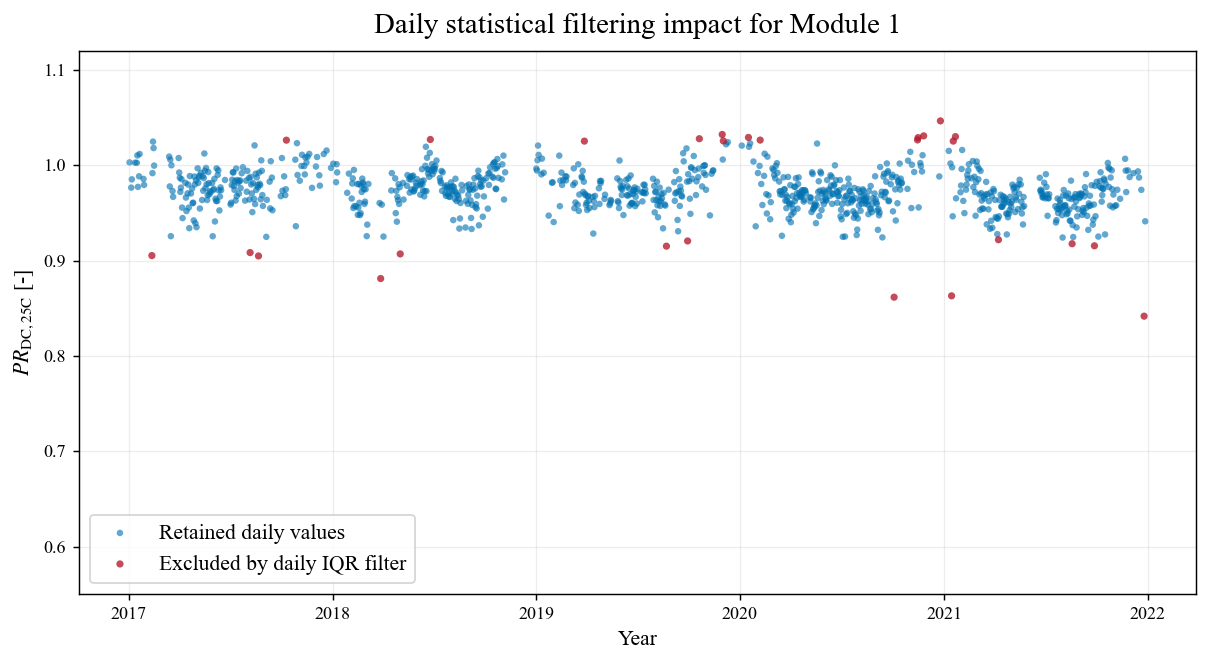

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_02.png


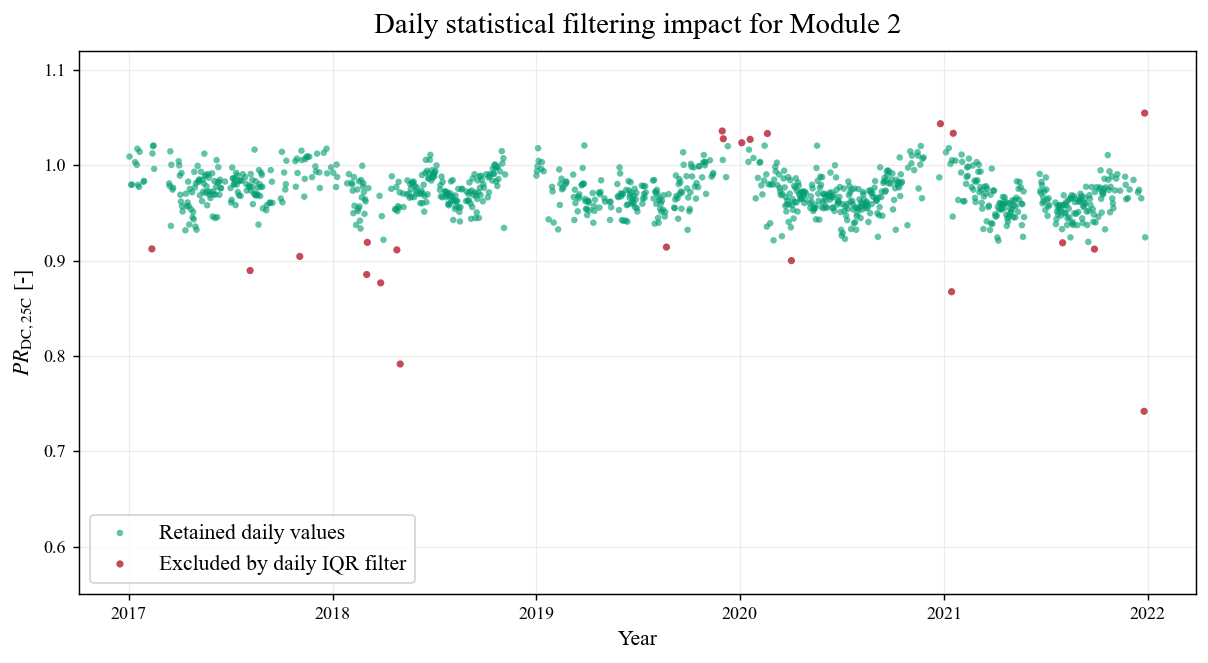

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_03.png


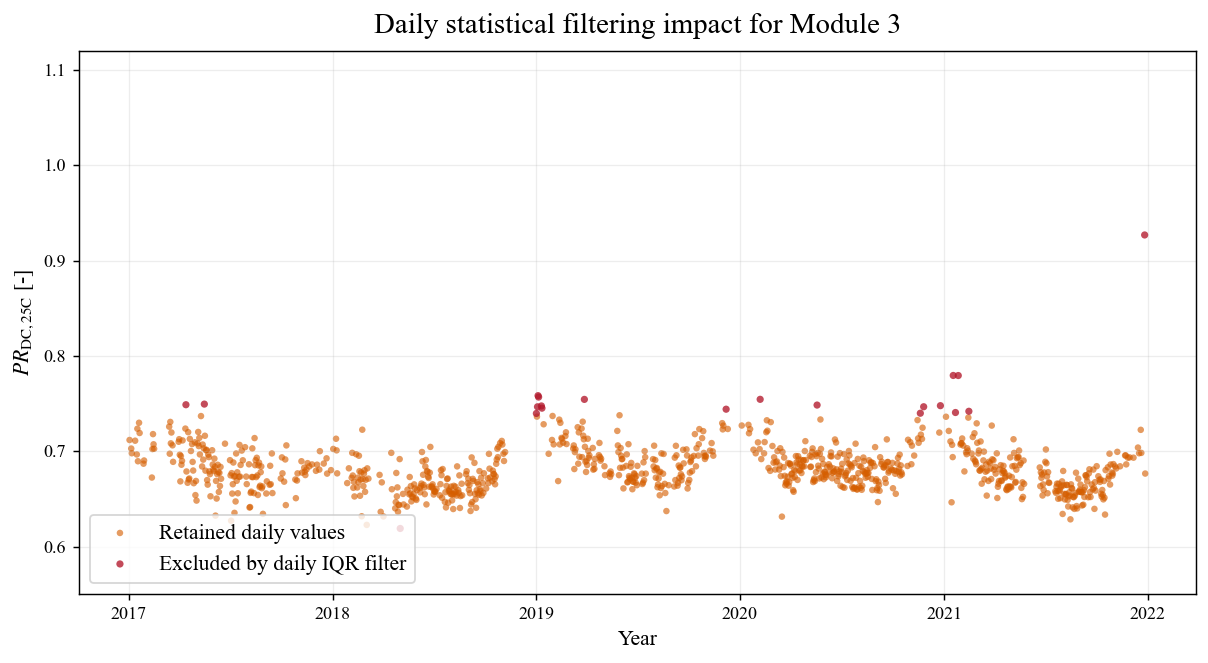

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_04.png


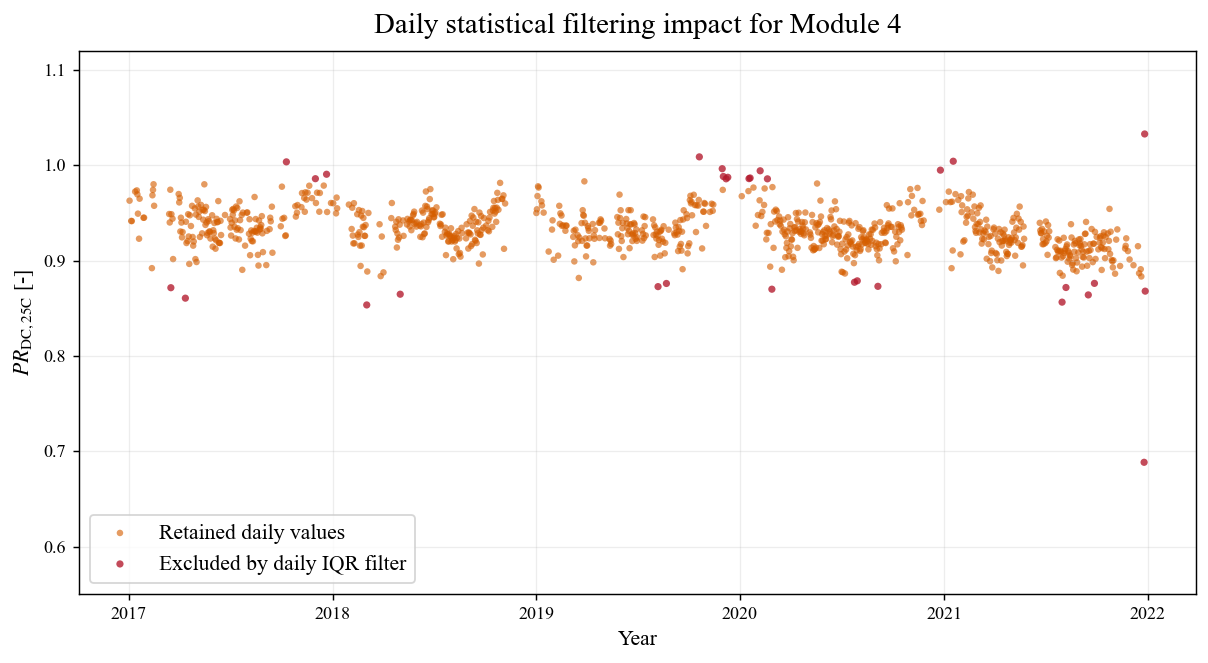

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_05.png


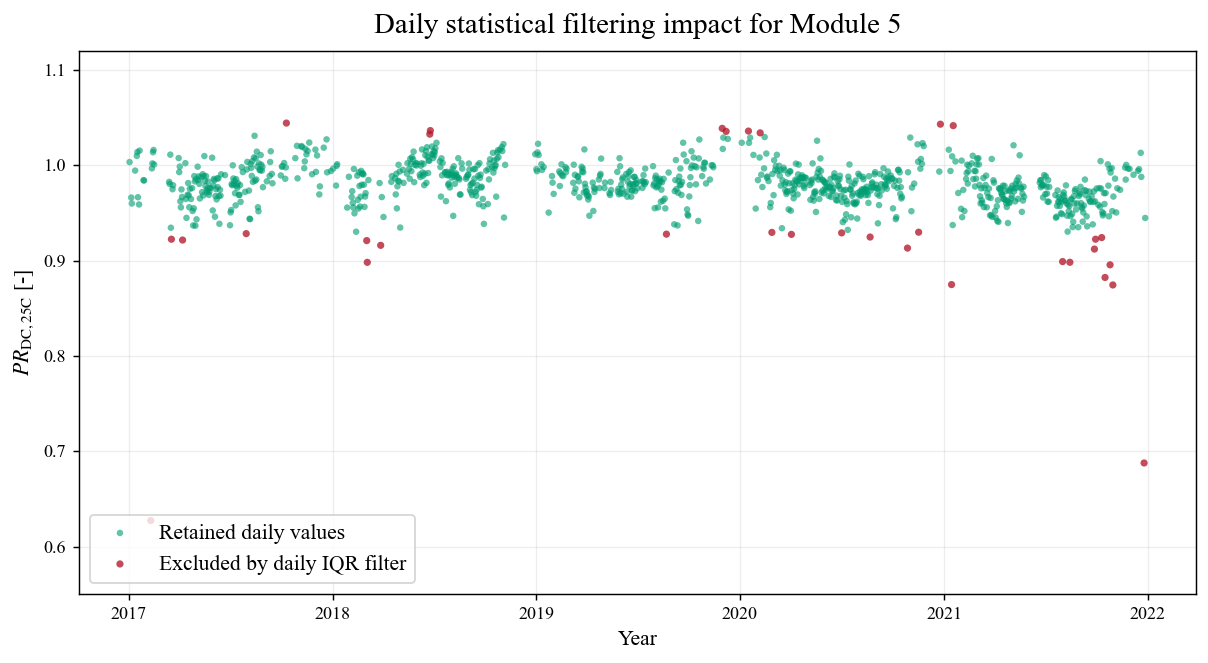

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_06.png


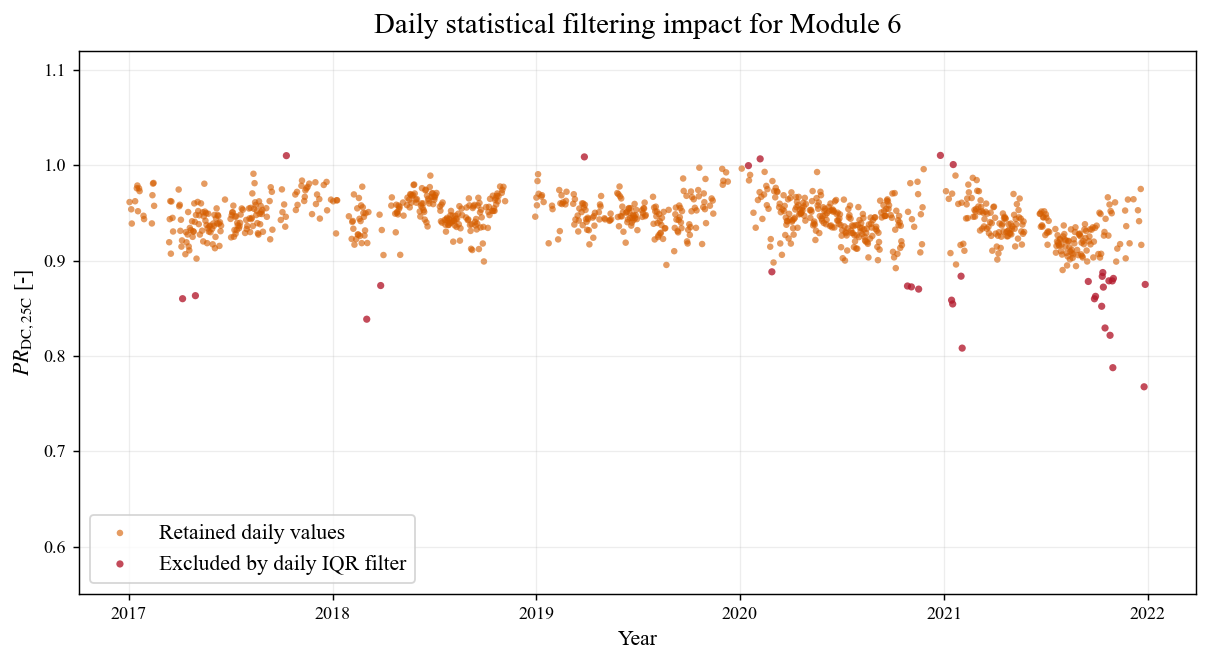

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_07.png


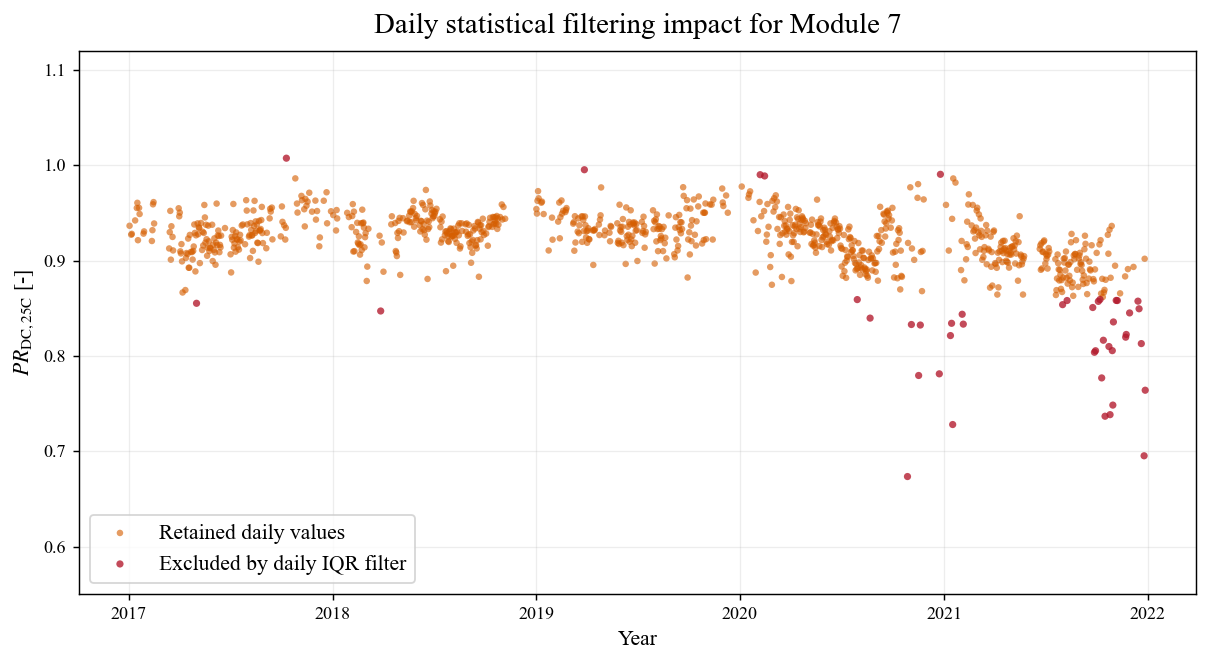

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_08.png


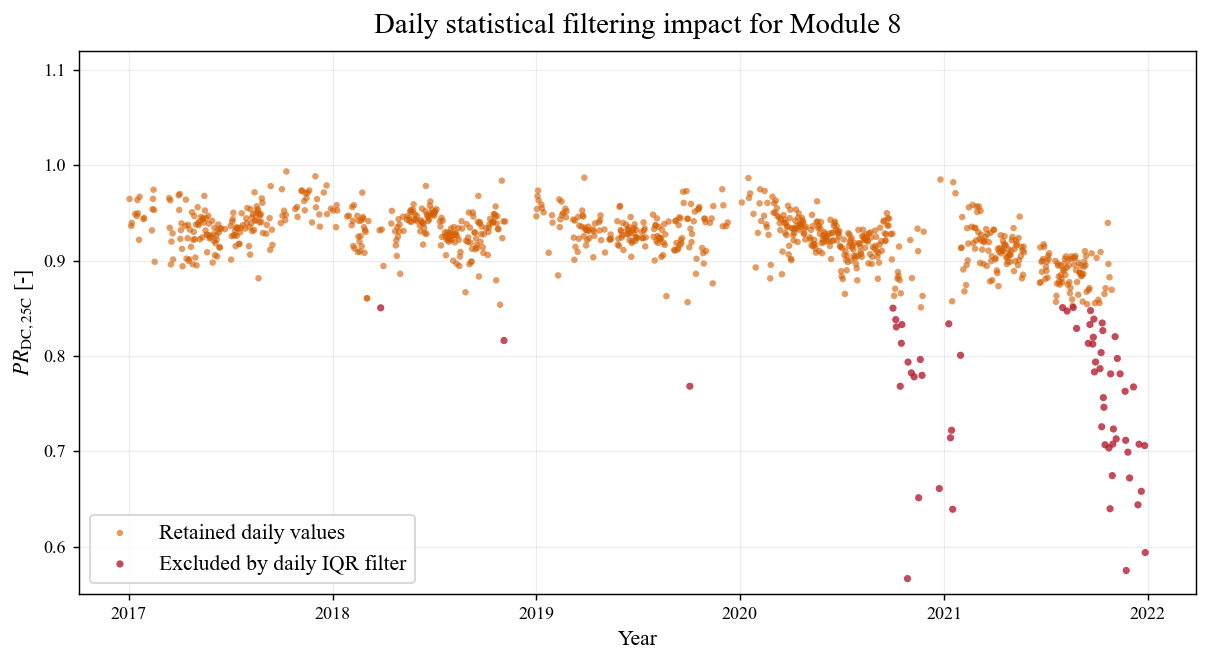

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_09.png


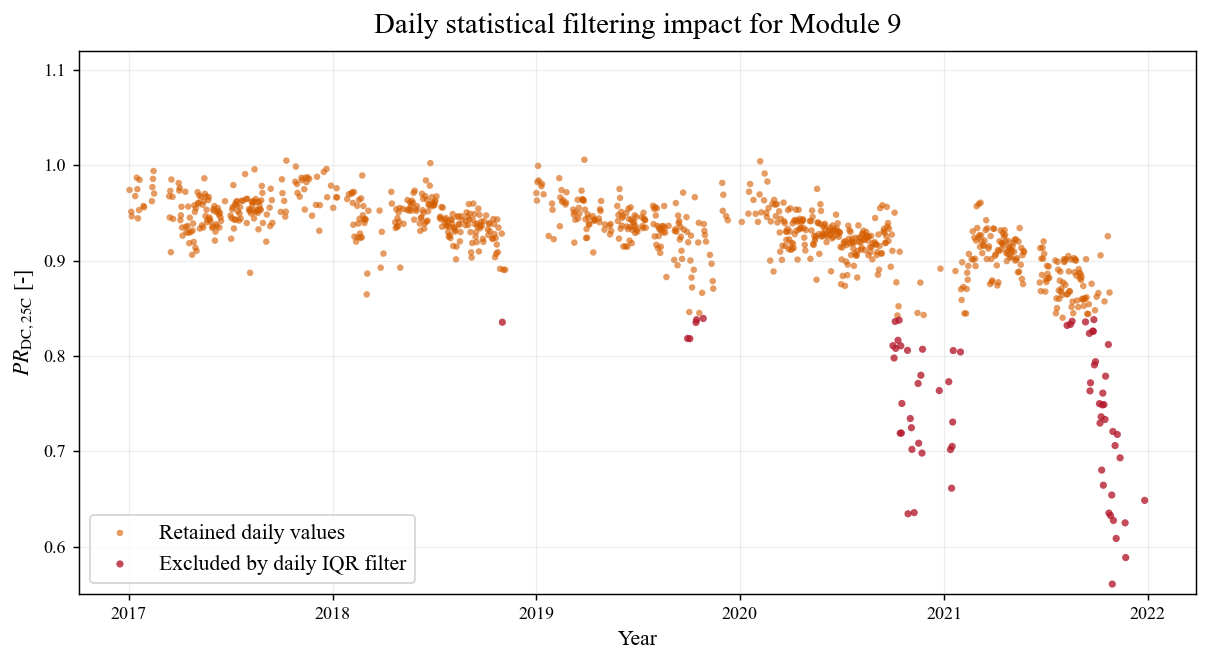

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_iqr_filtering_impact_g200_module_10.png


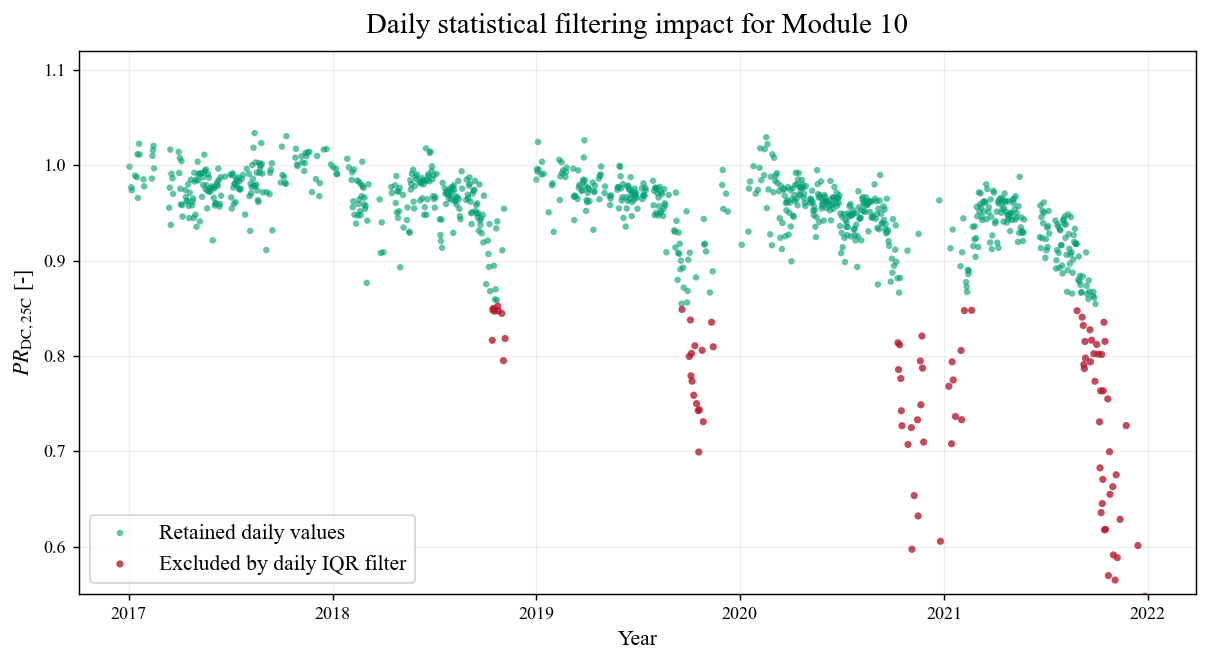

Daily IQR filtering impact figures exported for all modules in g200.


In [35]:
for module_id in range(1, 11):
    plot_daily_iqr_filtering_impact_one_module(
        daily_before=daily_datasets["g200"],
        daily_after=daily_filtered_datasets["g200"],
        module_id=module_id,
        dataset_name="g200",
        save=True,
        show=True,
    )

print("Daily IQR filtering impact figures exported for all modules in g200.")

## 13. Temperature-correction impact figures

The effect of temperature correction is visualised by comparing raw DC performance ratio with \(PR_\mathrm{DC,25C}\). Separate figures are exported for each module using the g200 dataset.

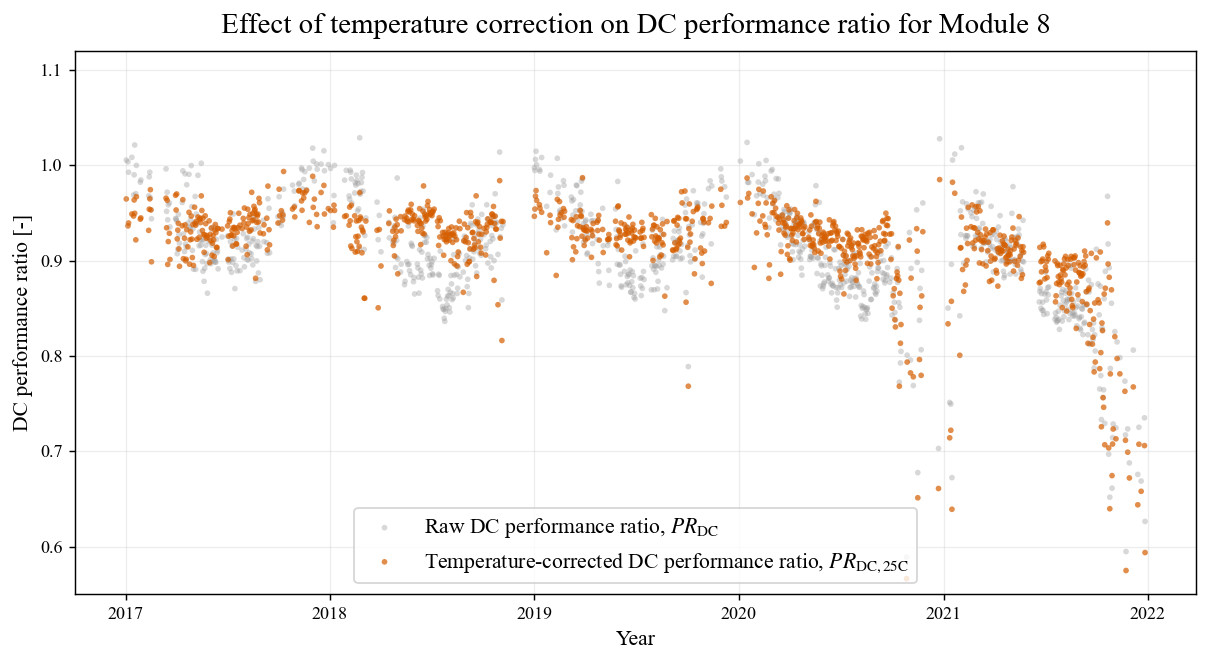

Temperature-correction figures exported for all modules.


In [23]:
def plot_daily_temperature_correction_impact(
    daily_input,
    module_id,
    save=True,
    show=True,
):
    """
    Plot daily raw and temperature-corrected DC performance ratio for one module.

    This uses daily aggregated values rather than row-level values so that
    isolated row-level artefacts do not dominate the y-axis.
    """
    plot_df = daily_input.loc[daily_input["Module_ID"] == module_id].copy()
    plot_df = plot_df.sort_values("Date")

    module_type = MODULE_TYPE_MAP[module_id]
    module_color = TYPE_COLORS[module_type]

    fig, ax = plt.subplots(figsize=(9.4, 5.2))

    ax.scatter(
        plot_df["Date"],
        plot_df["PR_raw"],
        s=10,
        alpha=0.40,
        color="#9E9E9E",
        edgecolors="none",
        label=r"Raw DC performance ratio, $PR_\mathrm{DC}$",
    )

    ax.scatter(
        plot_df["Date"],
        plot_df["PR_25C"],
        s=10,
        alpha=0.70,
        color=module_color,
        edgecolors="none",
        label=r"Temperature-corrected DC performance ratio, $PR_\mathrm{DC,25C}$",
    )

    ax.set_title(
        f"Effect of temperature correction on DC performance ratio for Module {module_id}",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Year", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("DC performance ratio [-]", fontsize=AXIS_LABEL_SIZE)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Fixed thesis-ready axis range.
    # This keeps all module figures comparable and avoids row-level artefact scaling.
    ax.set_ylim(0.55, 1.12)

    ax.legend(
        loc="lower center",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save:
        save_fig(
            f"temperature_correction_impact_daily_module_{module_id:02d}.png",
            fig,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)


plot_daily_temperature_correction_impact(
    daily_input=daily_datasets["g200"],
    module_id=8,
    save=False,
    show=True,
)

print("Temperature-correction figures exported for all modules.")

## 14. Aggregate to monthly PLR inputs

Monthly \(PR_\mathrm{DC,25C}\) is calculated from retained daily values using a yield-based ratio of sums:

\[
PR_{\mathrm{DC,25C,month}} =
\frac{\sum E_{\mathrm{MPP,25C,day}}}
{\sum E_{\mathrm{reference,day}}}
\]

A monthly value is retained only when at least 10 valid daily observations are available for that module-month.

In [26]:
def aggregate_one_month(group):
    group = group.copy()

    energy_raw_Wh = group["energy_raw_Wh"].sum()
    energy_25C_Wh = group["energy_25C_Wh"].sum()
    reference_energy_Wh = group["reference_energy_Wh"].sum()

    H_POA_Wh_m2 = group["H_POA_Wh_m2"].sum()
    Y_ref_h = group["Y_ref_h"].sum()

    return {
        "PR_25C": safe_ratio(energy_25C_Wh, reference_energy_Wh),
        "PR_raw": safe_ratio(energy_raw_Wh, reference_energy_Wh),

        "energy_raw_Wh": energy_raw_Wh,
        "energy_25C_Wh": energy_25C_Wh,
        "reference_energy_Wh": reference_energy_Wh,
        "H_POA_Wh_m2": H_POA_Wh_m2,
        "Y_ref_h": Y_ref_h,

        "P_MPP": group["P_MPP"].median(),
        "P_MPP_25C": group["P_MPP_25C"].median(),
        "P_STC": group["P_STC"].iloc[0],

        "G_POA": group["G_POA"].median(),
        "T_module": group["T_module"].median(),

        "FF_measured": group["FF_measured"].median(),
        "I_MPP_over_I_SC": group["I_MPP_over_I_SC"].median(),
        "V_MPP_over_V_OC": group["V_MPP_over_V_OC"].median(),

        "PR_25C_rel_fleet": group["PR_25C_rel_fleet"].median(),
        "P_MPP_rel_fleet": group["P_MPP_rel_fleet"].median(),
        "I_MPP_rel_fleet": group["I_MPP_rel_fleet"].median(),
        "V_MPP_rel_fleet": group["V_MPP_rel_fleet"].median(),

        "n_days_month": group["Date"].nunique(),
        "first_day": group["Date"].min(),
        "last_day": group["Date"].max(),
        "median_15min_values_per_day": group["n_15min_day"].median(),
    }


def aggregate_to_monthly(daily_filtered_input, dataset_name):
    monthly_rows = []

    for keys, group in daily_filtered_input.groupby(["Module_ID", "Type", "YearMonth"], sort=False):
        row = dict(zip(["Module_ID", "Type", "YearMonth"], keys))
        row.update(aggregate_one_month(group))
        monthly_rows.append(row)

    monthly = pd.DataFrame(monthly_rows)

    monthly["Month_Start"] = pd.to_datetime(monthly["YearMonth"])
    monthly["Year"] = monthly["Month_Start"].dt.year
    monthly["Month"] = monthly["Month_Start"].dt.month
    monthly["dataset"] = dataset_name

    monthly["monthly_support_valid"] = monthly["n_days_month"] >= MIN_DAYS_MONTH

    monthly_supported = (
        monthly.loc[monthly["monthly_support_valid"]]
        .sort_values(["Module_ID", "Month_Start"])
        .reset_index(drop=True)
    )

    support_summary = pd.DataFrame([{
        "Dataset": dataset_name,
        "Monthly records before support filter": len(monthly),
        "Monthly records after support filter": len(monthly_supported),
        "Monthly records excluded": len(monthly) - len(monthly_supported),
        "Minimum days per retained month": MIN_DAYS_MONTH,
        "Median days per retained month": monthly_supported["n_days_month"].median(),
    }])

    return monthly_supported, support_summary


monthly_datasets = {}
monthly_support_summaries = []

for dataset_name, daily_filtered in daily_filtered_datasets.items():
    monthly_datasets[dataset_name], summary = aggregate_to_monthly(
        daily_filtered,
        dataset_name=dataset_name,
    )

    monthly_support_summaries.append(summary)

monthly_support_summary = pd.concat(monthly_support_summaries, ignore_index=True)

display(monthly_support_summary)

,Dataset,Monthly records before support filter,Monthly records after support filter,Monthly records excluded,Minimum days per retained month,Median days per retained month
0,g200,583,415,168,10,21.0
1,g400,569,356,213,10,19.0
2,sunny,563,138,425,10,14.0


In [29]:
monthly_before_iqr_g200, _ = aggregate_to_monthly(
    daily_datasets["g200"],
    dataset_name="g200_before_daily_iqr",
)

### Plots of daily and monthly PR_DC,25

In [36]:
def plot_pr25c_time_series_all_modules(
    data,
    time_col,
    frequency_label,
    plot_style="scatter",
    dataset_name="g200",
    save=True,
    show=True,
):
    """
    Plot PR_DC,25C time series for all modules.

    plot_style options:
    - "scatter"
    - "line"
    """

    fig, ax = plt.subplots(figsize=(10.2, 5.8))

    for module_id in sorted(data["Module_ID"].unique()):
        module_df = data.loc[data["Module_ID"] == module_id].copy()
        module_df = module_df.sort_values(time_col)

        label = f"M{module_id} ({MODULE_TYPE_MAP[module_id]})"
        color = MODULE_COLOR_MAP[module_id]

        if plot_style == "scatter":
            ax.scatter(
                module_df[time_col],
                module_df["PR_25C"],
                s=14 if frequency_label == "monthly" else 6,
                alpha=0.76 if frequency_label == "monthly" else 0.36,
                color=color,
                edgecolors="none",
                label=label,
            )

        elif plot_style == "line":
            ax.plot(
                module_df[time_col],
                module_df["PR_25C"],
                marker="o",
                markersize=3.5 if frequency_label == "monthly" else 2.0,
                linewidth=1.1 if frequency_label == "monthly" else 0.55,
                alpha=0.82 if frequency_label == "monthly" else 0.38,
                color=color,
                label=label,
            )

        else:
            raise ValueError("plot_style must be either 'scatter' or 'line'.")

    ax.set_title(
        rf"Temporal evolution of {frequency_label} $PR_\mathrm{{DC,25C}}$ across all modules",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Year", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(r"$PR_\mathrm{DC,25C}$ [-]", fontsize=AXIS_LABEL_SIZE)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Keep same scale across all daily/monthly PR plots
    ax.set_ylim(0.62, 1.03)

    ax.legend(
        title="Module",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
        fontsize=9,
        title_fontsize=10,
    )

    fig.tight_layout()

    if save:
        save_fig(
            f"{frequency_label}_prdc25c_{plot_style}_all_modules_{dataset_name}.png",
            fig,
        )

    if show:
        plt.show()
    else:
        plt.close(fig)

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_prdc25c_scatter_all_modules_g200.png


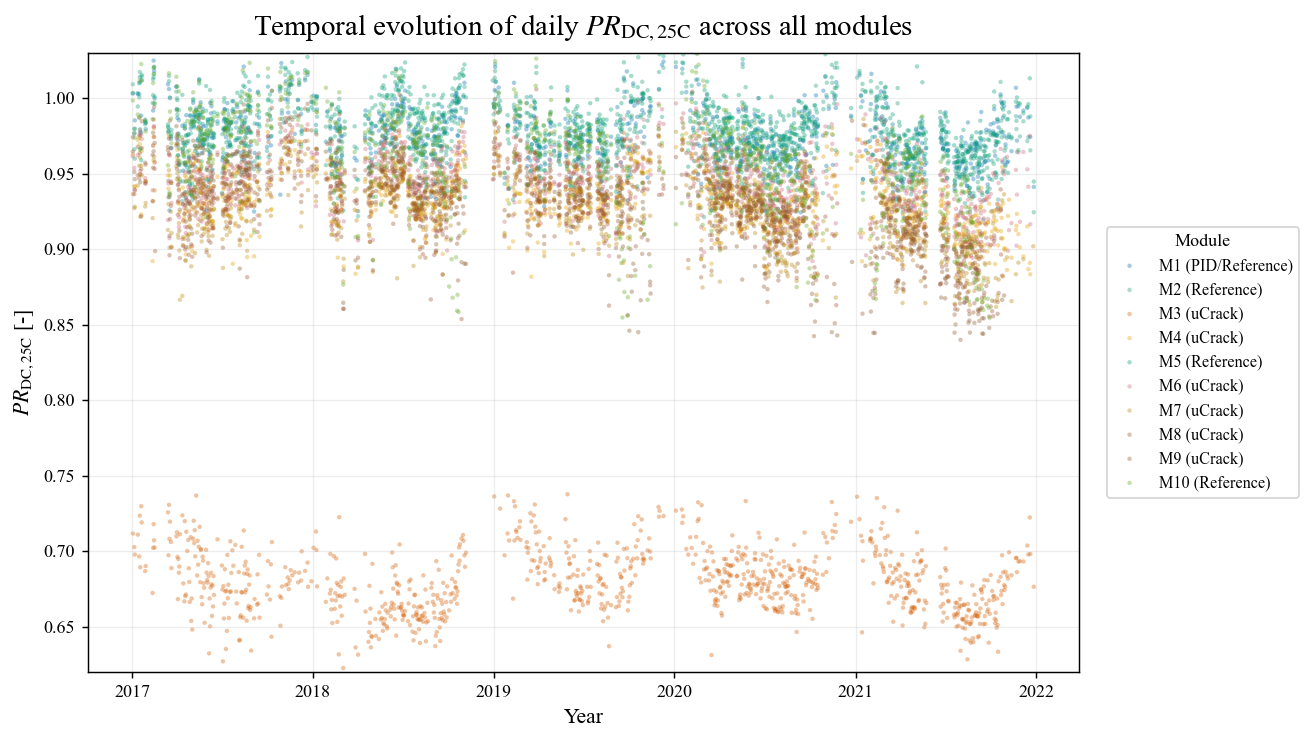

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\daily_prdc25c_line_all_modules_g200.png


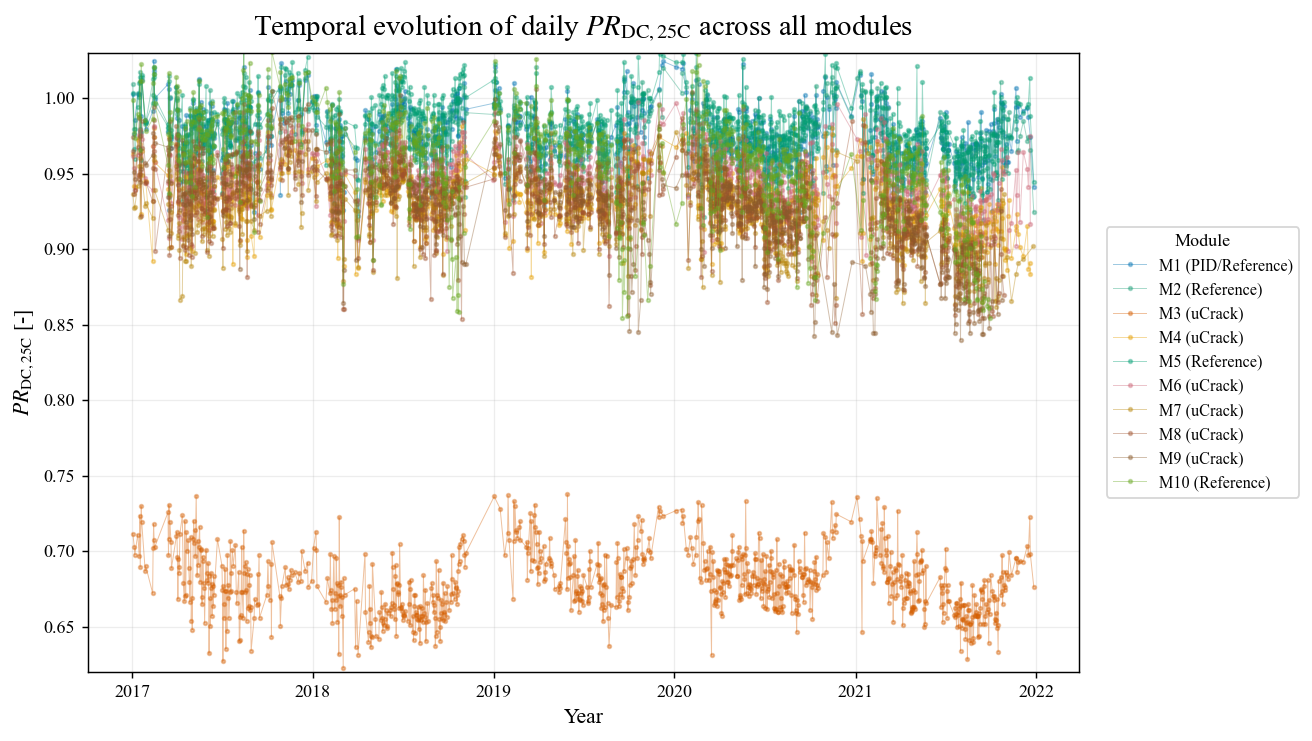

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\monthly_prdc25c_scatter_all_modules_g200.png


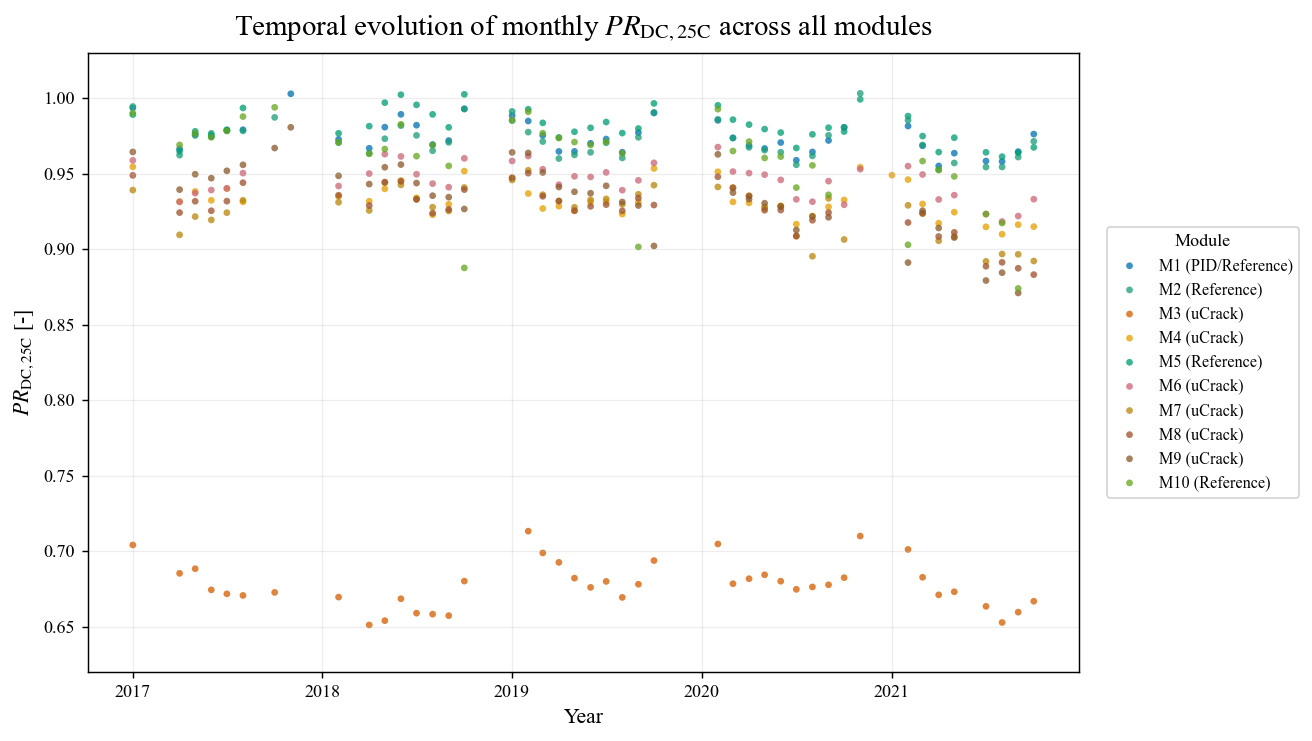

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\monthly_prdc25c_line_all_modules_g200.png


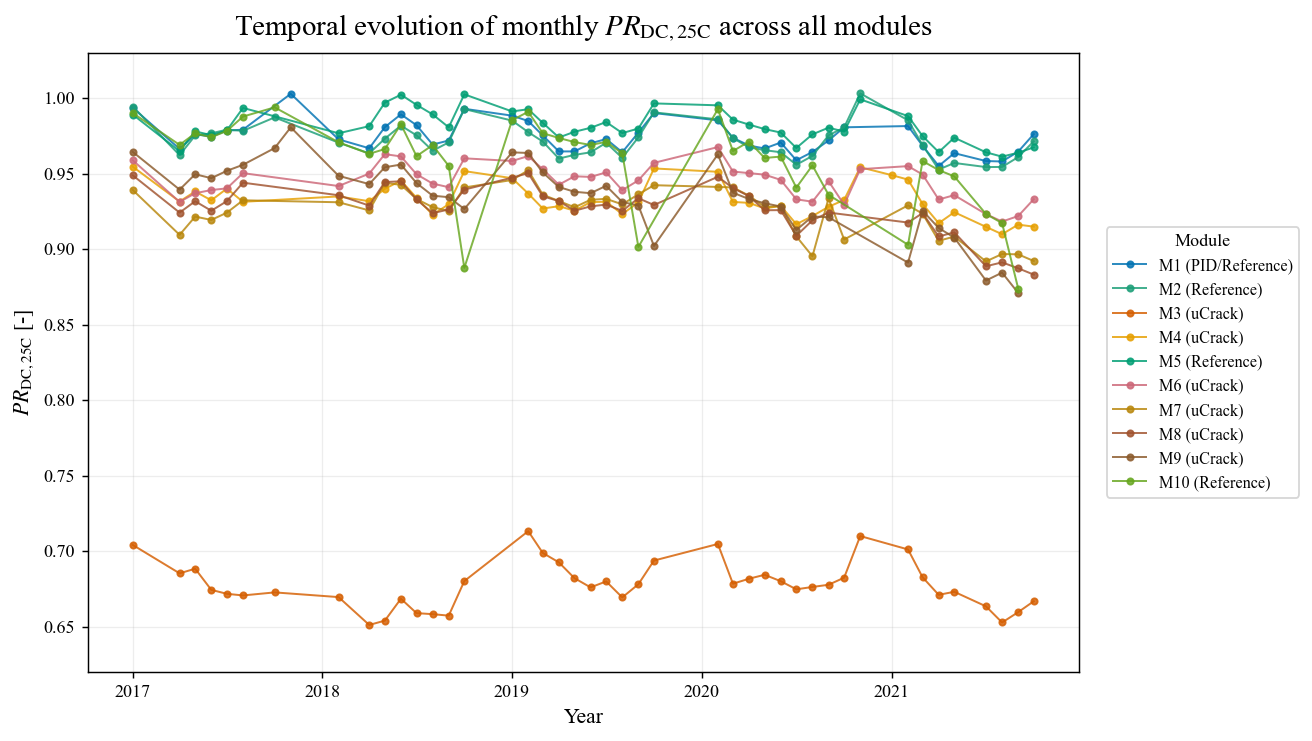

In [37]:
# Daily scatter
plot_pr25c_time_series_all_modules(
    data=daily_filtered_datasets["g200"],
    time_col="Date",
    frequency_label="daily",
    plot_style="scatter",
    dataset_name="g200",
    save=True,
    show=True,
)

# Daily line
plot_pr25c_time_series_all_modules(
    data=daily_filtered_datasets["g200"],
    time_col="Date",
    frequency_label="daily",
    plot_style="line",
    dataset_name="g200",
    save=True,
    show=True,
)

# Monthly scatter
plot_pr25c_time_series_all_modules(
    data=monthly_datasets["g200"],
    time_col="Month_Start",
    frequency_label="monthly",
    plot_style="scatter",
    dataset_name="g200",
    save=True,
    show=True,
)

# Monthly line
plot_pr25c_time_series_all_modules(
    data=monthly_datasets["g200"],
    time_col="Month_Start",
    frequency_label="monthly",
    plot_style="line",
    dataset_name="g200",
    save=True,
    show=True,
)